In [1]:
import sqlite3
import matplotlib.pyplot as plt
import numpy as np
import datetime

conn = sqlite3.connect("sales_data_analysis.db")
cursor = conn.cursor()

In [2]:
cursor.execute("""
    CREATE TABLE sales (
        id INTEGER PRIMARY KEY,
        shop_name TEXT,
        item_name TEXT,
        quantity INTEGER,
        unit_price REAL,
        sale_date TEXT
    )
""")
sales_data_analysis = [
    (1, "Brewed Awakening Café", "Coffee", 30, 10.50, "2023-10-01"),
    (2, "Brewed Awakening Café", "Tea", 25, 15.00, "2023-10-01"),
    (3, "Brewed Awakening Café", "Muffin", 70, 30.00, "2023-10-02"),
    (4, "Brewed Awakening Café", "Bagel", 80, 35.75, "2023-10-02"),
    (5, "Brewed Awakening Café", "Coffee", 50, 15.50, "2023-10-03"),
    (6, "Brewed Awakening Café", "Dark chocolate mocha", 150, 60.70, "2023-10-04"),
    (7, "Brewed Awakening Café", "Cappuccino", 130, 70.00, "2023-10-05"),
    (8, "Brewed Awakening Café", "Coffee flavored pastry", 100, 50.00, "2023-10-06" ),
    (9, "Brewed Awakening Café", "Black forest pastry", 120, 55.30, "2023-10-06"),
    (10, "Brewed Awakening Café", "Macha latte", 200, 100.50, "2023-10-07")
]

cursor.executemany("INSERT INTO sales VALUES (?, ?, ?, ?, ?, ?)", sales_data_analysis)
conn.commit()

cursor.execute("SELECT * FROM sales")
for row in cursor.fetchall():
    print(row)

(1, 'Brewed Awakening Café', 'Coffee', 30, 10.5, '2023-10-01')
(2, 'Brewed Awakening Café', 'Tea', 25, 15.0, '2023-10-01')
(3, 'Brewed Awakening Café', 'Muffin', 70, 30.0, '2023-10-02')
(4, 'Brewed Awakening Café', 'Bagel', 80, 35.75, '2023-10-02')
(5, 'Brewed Awakening Café', 'Coffee', 50, 15.5, '2023-10-03')
(6, 'Brewed Awakening Café', 'Dark chocolate mocha', 150, 60.7, '2023-10-04')
(7, 'Brewed Awakening Café', 'Cappuccino', 130, 70.0, '2023-10-05')
(8, 'Brewed Awakening Café', 'Coffee flavored pastry', 100, 50.0, '2023-10-06')
(9, 'Brewed Awakening Café', 'Black forest pastry', 120, 55.3, '2023-10-06')
(10, 'Brewed Awakening Café', 'Macha latte', 200, 100.5, '2023-10-07')


In [3]:
query = """
    SELECT item_name,
           SUM(quantity) AS total_quantity,
           SUM(quantity * unit_price) AS total_revenue
    FROM sales
    GROUP BY item_name
"""
cursor.execute(query)
results = cursor.fetchall()

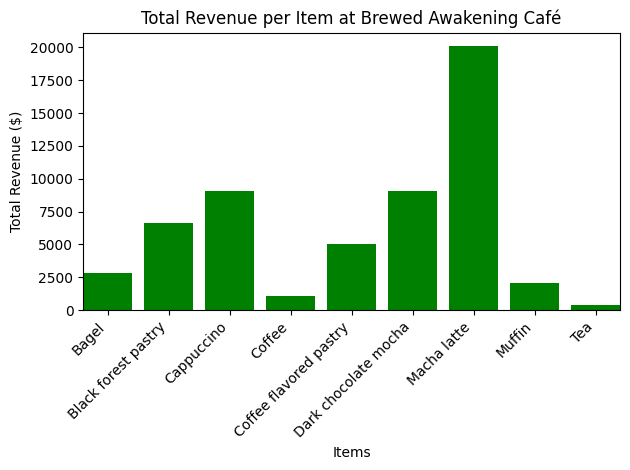

In [4]:
items, quantities, revenues = zip(*results)
positions = np.arange(len(items))

plt.bar(items, revenues, color='Green')

plt.xticks(positions, items, rotation=45, ha='right')
plt.margins(x=0)
plt.subplots_adjust(bottom=0.15)

plt.xlabel("Items")
plt.ylabel("Total Revenue ($)")
plt.title("Total Revenue per Item at Brewed Awakening Café")
plt.tight_layout()
plt.show()

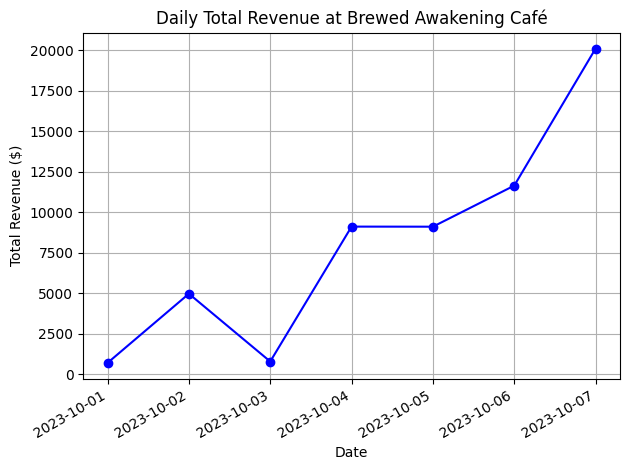

In [5]:
dates = []
revenues = []

query = """
    SELECT sale_date,
           SUM(quantity * unit_price) AS total_revenue
    FROM sales
    GROUP BY sale_date
    ORDER BY sale_date
"""
cursor.execute(query)
results = cursor.fetchall()

for row in results:
    sale_date = row[0]
    total_revenue = row[1]
    date_obj = datetime.datetime.strptime(sale_date, "%Y-%m-%d")
    dates.append(date_obj)
    revenues.append(total_revenue)

plt.plot(dates, revenues, marker='o', linestyle='-', color='blue')
plt.xlabel("Date")
plt.ylabel("Total Revenue ($)")
plt.title("Daily Total Revenue at Brewed Awakening Café")
plt.grid(True)

plt.gcf().autofmt_xdate()

plt.tight_layout()
plt.show()

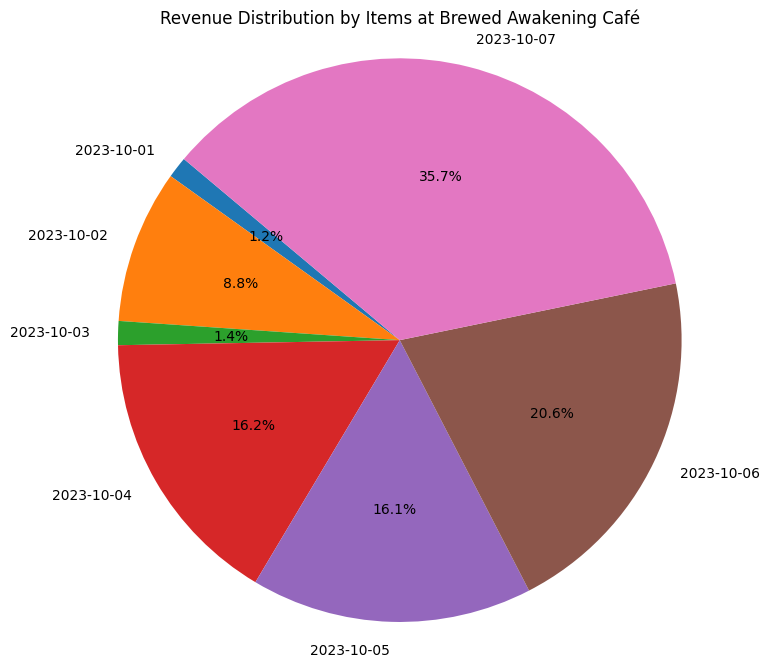

In [6]:
labels = [row[0] for row in results]
sizes = [row[1] for row in results]

plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
plt.title("Revenue Distribution by Items at Brewed Awakening Café")
plt.axis("equal")
plt.show()


In [10]:
import pandas as pd

df = pd.DataFrame(sales_data_analysis, columns=['id', 'shop_name', 'item_name', 'quantity', 'unit_price', 'sale_date'])

df['revenue'] = df['quantity'] * df['unit_price']

print("Total Revenue:", df['revenue'].sum())
print("Total Quantity Sold:", df['quantity'].sum())
print("Average Price per Unit:", df['unit_price'].mean())

Total Revenue: 56366.0
Total Quantity Sold: 955
Average Price per Unit: 44.325


In [11]:
query = """
    SELECT item_name,
           SUM(quantity) AS total_quantity,
           SUM(quantity * unit_price) AS total_revenue
    FROM sales
    GROUP BY item_name
"""
cursor.execute(query)
results_items = cursor.fetchall()


print("Sales Summary for Brewed Awakening Café:")
for row in results_items:
    item, total_quantity, total_revenue = row
    print(f"{item}: Total Quantity Sold = {total_quantity}, Total Revenue = ${total_revenue:.2f}")

Sales Summary for Brewed Awakening Café:
Bagel: Total Quantity Sold = 80, Total Revenue = $2860.00
Black forest pastry: Total Quantity Sold = 120, Total Revenue = $6636.00
Cappuccino: Total Quantity Sold = 130, Total Revenue = $9100.00
Coffee: Total Quantity Sold = 80, Total Revenue = $1090.00
Coffee flavored pastry: Total Quantity Sold = 100, Total Revenue = $5000.00
Dark chocolate mocha: Total Quantity Sold = 150, Total Revenue = $9105.00
Macha latte: Total Quantity Sold = 200, Total Revenue = $20100.00
Muffin: Total Quantity Sold = 70, Total Revenue = $2100.00
Tea: Total Quantity Sold = 25, Total Revenue = $375.00


In [12]:
conn.close()